# Ingestion Pipeline Benchmark Analysis

Reads the CSV logs produced by `samuraimpt bench-ingest` and generates
throughput / latency plots suitable for a research paper.

**Inputs** (produced by the Go instrumentation):
- `blocks.csv` -- per-block metrics (20 columns)
- `summary.csv` -- key-value benchmark configuration and totals

**Trimming**: Set `trim_start_sec` / `trim_end_sec` to exclude warmup and
cooldown from computed statistics and plots.

In [3]:
# ============================================================
# Configuration -- edit these parameters for each analysis run
# ============================================================

# Paths to benchmark output files
BENCHMARK_DIR = "../../benchmark_output/ingest"
BLOCKS_CSV    = f"{BENCHMARK_DIR}/blocks.csv"
SUMMARY_CSV   = f"{BENCHMARK_DIR}/summary.csv"

# Trim warmup / cooldown (seconds from start / end)
trim_start_sec = 0    # seconds to trim from the beginning
trim_end_sec   = 0    # seconds to trim from the end

# Windowing for throughput and latency over time
throughput_window_sec = 5
latency_window_sec   = 5

# Output directory for saved figures
FIGURES_DIR = f"{BENCHMARK_DIR}/figures"

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs(FIGURES_DIR, exist_ok=True)

# Matplotlib defaults for research-quality output
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 1.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

## Helper functions

In [5]:
def load_blocks(path: str) -> pd.DataFrame:
    """Load blocks.csv and derive relative time columns."""
    df = pd.read_csv(path)
    # Derive relative seconds from the first emitted_at timestamp
    t0 = df["emitted_at_ns"].min()
    df["rel_emitted_sec"]   = (df["emitted_at_ns"]   - t0) / 1e9
    df["rel_mpt_start_sec"] = (df["mpt_start_at_ns"] - t0) / 1e9
    df["rel_completed_sec"] = (df["completed_at_ns"]  - t0) / 1e9
    return df


def load_summary(path: str) -> dict:
    """Load summary.csv (key-value format) into a dict."""
    df = pd.read_csv(path)
    return dict(zip(df["key"], df["value"]))


def trim(df: pd.DataFrame, start_sec: float, end_sec: float) -> pd.DataFrame:
    """Trim rows outside the [start_sec, max - end_sec] window."""
    tmax = df["rel_completed_sec"].max()
    mask = (df["rel_completed_sec"] >= start_sec) & (df["rel_completed_sec"] <= tmax - end_sec)
    return df[mask].copy()


def fixed_window_throughput(df: pd.DataFrame, time_col: str, value_col: str,
                            window_sec: float) -> pd.DataFrame:
    """Compute rate (value_col sum / window width) in fixed-width time bins.

    Returns DataFrame with columns: bin_mid, rate.
    """
    t_min = df[time_col].min()
    t_max = df[time_col].max()
    bins = np.arange(t_min, t_max + window_sec, window_sec)
    df = df.copy()
    df["_bin"] = pd.cut(df[time_col], bins=bins, right=False)
    grouped = df.groupby("_bin", observed=True)
    result = pd.DataFrame({
        "bin_mid": grouped[time_col].mean(),
        "rate": grouped[value_col].sum() / window_sec,
    }).dropna().reset_index(drop=True)
    return result


def fixed_window_count_rate(df: pd.DataFrame, time_col: str,
                            window_sec: float) -> pd.DataFrame:
    """Compute count / window width in fixed-width time bins (for blocks/sec)."""
    t_min = df[time_col].min()
    t_max = df[time_col].max()
    bins = np.arange(t_min, t_max + window_sec, window_sec)
    df = df.copy()
    df["_bin"] = pd.cut(df[time_col], bins=bins, right=False)
    grouped = df.groupby("_bin", observed=True)
    result = pd.DataFrame({
        "bin_mid": grouped[time_col].mean(),
        "rate": grouped.size() / window_sec,
    }).dropna().reset_index(drop=True)
    return result


def fixed_window_mean(df: pd.DataFrame, time_col: str, value_col: str,
                      window_sec: float) -> pd.DataFrame:
    """Compute mean of value_col in fixed-width time bins."""
    t_min = df[time_col].min()
    t_max = df[time_col].max()
    bins = np.arange(t_min, t_max + window_sec, window_sec)
    df = df.copy()
    df["_bin"] = pd.cut(df[time_col], bins=bins, right=False)
    grouped = df.groupby("_bin", observed=True)
    result = pd.DataFrame({
        "bin_mid": grouped[time_col].mean(),
        "mean": grouped[value_col].mean(),
    }).dropna().reset_index(drop=True)
    return result


def fixed_window_weighted_mean(df: pd.DataFrame, time_col: str,
                               value_col: str, weight_col: str,
                               window_sec: float) -> pd.DataFrame:
    """Compute weighted mean of value_col in fixed-width time bins."""
    t_min = df[time_col].min()
    t_max = df[time_col].max()
    bins = np.arange(t_min, t_max + window_sec, window_sec)
    df = df.copy()
    df["_bin"] = pd.cut(df[time_col], bins=bins, right=False)
    df["_wv"] = df[value_col] * df[weight_col]
    grouped = df.groupby("_bin", observed=True)
    wsum = grouped["_wv"].sum()
    wcount = grouped[weight_col].sum()
    result = pd.DataFrame({
        "bin_mid": grouped[time_col].mean(),
        "wmean": (wsum / wcount).replace([np.inf, -np.inf], np.nan),
    }).dropna().reset_index(drop=True)
    return result


def percentile_stats(series: pd.Series, name: str) -> pd.DataFrame:
    """Return a single-row DataFrame with mean, p50, p95, p99, max."""
    return pd.DataFrame([{
        "metric": name,
        "mean":  series.mean(),
        "p50":   series.quantile(0.50),
        "p95":   series.quantile(0.95),
        "p99":   series.quantile(0.99),
        "max":   series.max(),
    }])


def save_fig(fig, name: str):
    """Save figure to FIGURES_DIR as both PNG and PDF."""
    fig.savefig(os.path.join(FIGURES_DIR, f"{name}.png"), bbox_inches="tight")
    fig.savefig(os.path.join(FIGURES_DIR, f"{name}.pdf"), bbox_inches="tight")
    print(f"  saved: {name}.png / .pdf")

## Load data

In [6]:
blocks_raw = load_blocks(BLOCKS_CSV)
print(f"Loaded {len(blocks_raw)} block rows from {BLOCKS_CSV}")
print(f"Block range: {blocks_raw['block_number'].min()} .. {blocks_raw['block_number'].max()}")
print(f"Time span: {blocks_raw['rel_completed_sec'].max():.1f}s")

summary = {}
if os.path.exists(SUMMARY_CSV):
    summary = load_summary(SUMMARY_CSV)
    print("\nBenchmark summary:")
    for k, v in summary.items():
        print(f"  {k}: {v}")
else:
    print(f"\nWarning: {SUMMARY_CSV} not found, skipping summary.")

blocks_raw.head()

Loaded 17566 block rows from ../../benchmark_output/ingest/blocks.csv
Block range: 18908895 .. 18926460
Time span: 300.2s

Benchmark summary:
  start_block: 18908895.0
  configured_duration_sec: 300.0
  num_users: 0.0
  bench_start_ns: 1.7738314624072212e+18
  bench_end_ns: 1.7738317626420498e+18
  wall_clock_sec: 300.235
  total_blocks: 17566.0
  total_raw_updates: 5581047.0
  total_selected_updates: 5581047.0
  total_discarded_updates: 0.0
  avg_e2e_updates_per_sec: 18588.94
  avg_e2e_blocks_per_sec: 58.51
  avg_commit_updates_per_sec: 18588.94


,block_number,raw_updates,selected_updates,discarded_updates,emitted_at_ns,mpt_start_at_ns,completed_at_ns,e2e_latency_ms,mpt_phase_latency_ms,wait_commitments_latency_ms,...,commit_latency_max_us,commit_latency_avg_us,queue_wait_count,queue_wait_sum_us,queue_wait_min_us,queue_wait_max_us,queue_wait_avg_us,rel_emitted_sec,rel_mpt_start_sec,rel_completed_sec
0,18908895,385,385,0,1773831462415971909,1773831462416074248,1773831462497180853,81.209,81.107,52.870,...,17335.636,3045.967,385,9.856123e+06,32.700,59366.145,25600.319,0.000000,0.000102,0.081209
1,18908896,466,466,0,1773831462416812392,1773831462497260262,1773831462512454016,95.642,15.194,0.049,...,14936.976,1165.937,466,2.170533e+07,5471.914,62588.259,46577.966,0.000840,0.081288,0.096482
2,18908897,258,258,0,1773831462417738564,1773831462512470336,1773831462530634875,112.896,18.165,0.038,...,13718.955,1076.081,258,1.527638e+07,21825.408,79452.228,59210.772,0.001767,0.096498,0.114663
3,18908898,291,291,0,1773831462417870293,1773831462530661295,1773831462537167110,119.297,6.506,0.027,...,11035.538,703.166,291,1.971342e+07,43713.526,83862.912,67743.713,0.001898,0.114689,0.121195
4,18908899,283,283,0,1773831462418083001,1773831462537190870,1773831462544493319,126.410,7.302,0.083,...,11903.591,944.752,283,2.096368e+07,57074.135,92286.092,74076.618,0.002111,0.121219,0.128521


## Apply trimming

In [7]:
df = trim(blocks_raw, trim_start_sec, trim_end_sec)

trimmed_duration = df["rel_completed_sec"].max() - df["rel_completed_sec"].min()
print(f"After trimming: {len(df)} blocks, {trimmed_duration:.1f}s analysis window")
print(f"  (trimmed {len(blocks_raw) - len(df)} blocks: "
      f"{trim_start_sec}s from start, {trim_end_sec}s from end)")

After trimming: 17566 blocks, 300.1s analysis window
  (trimmed 0 blocks: 0s from start, 0s from end)


## Summary statistics

In [8]:
total_raw       = df["raw_updates"].sum()
total_selected  = df["selected_updates"].sum()
total_discarded = df["discarded_updates"].sum()
n_blocks        = len(df)

e2e_ups = total_selected / trimmed_duration if trimmed_duration > 0 else 0
e2e_bps = n_blocks / trimmed_duration if trimmed_duration > 0 else 0

total_commits = df["commit_latency_count"].sum()
commit_ups = total_commits / trimmed_duration if trimmed_duration > 0 else 0

print("=" * 60)
print("BENCHMARK SUMMARY (after trimming)")
print("=" * 60)
print(f"  Analysis duration:       {trimmed_duration:>12.1f} s")
print(f"  Blocks processed:        {n_blocks:>12d}")
print(f"  Total raw updates:       {total_raw:>12d}")
print(f"  Total selected updates:  {total_selected:>12d}")
print(f"  Total discarded updates: {total_discarded:>12d}")
print(f"  E2E throughput:          {e2e_ups:>12.1f} updates/sec")
print(f"  E2E throughput:          {e2e_bps:>12.2f} blocks/sec")
print(f"  Commitment throughput:   {commit_ups:>12.1f} updates/sec")
print()

# Latency percentiles
latency_stats = pd.concat([
    percentile_stats(df["e2e_latency_ms"],              "E2E block latency (ms)"),
    percentile_stats(df["mpt_phase_latency_ms"],        "MPT phase latency (ms)"),
    percentile_stats(df["wait_commitments_latency_ms"], "Wait-for-commits (ms)"),
], ignore_index=True)

# Per-update commitment latency from per-block aggregates
valid_commit = df[df["commit_latency_count"] > 0]
if len(valid_commit) > 0:
    latency_stats = pd.concat([
        latency_stats,
        percentile_stats(valid_commit["commit_latency_avg_us"], "Commit latency avg/block (us)"),
    ], ignore_index=True)

valid_qw = df[df["queue_wait_count"] > 0]
if len(valid_qw) > 0:
    latency_stats = pd.concat([
        latency_stats,
        percentile_stats(valid_qw["queue_wait_avg_us"], "Queue wait avg/block (us)"),
    ], ignore_index=True)

print("LATENCY PERCENTILES")
print("-" * 60)
print(latency_stats.to_string(index=False, float_format="{:.2f}".format))

BENCHMARK SUMMARY (after trimming)
  Analysis duration:              300.1 s
  Blocks processed:               17566
  Total raw updates:            5581047
  Total selected updates:       5581047
  Total discarded updates:            0
  E2E throughput:               18594.5 updates/sec
  E2E throughput:                 58.53 blocks/sec
  Commitment throughput:        18594.5 updates/sec

LATENCY PERCENTILES
------------------------------------------------------------
                       metric    mean     p50     p95     p99       max
       E2E block latency (ms)  204.82  200.21  291.47  332.91    823.53
       MPT phase latency (ms)   17.08   16.15   27.73   37.22    512.35
        Wait-for-commits (ms)    0.05    0.05    0.07    0.10     52.87
Commit latency avg/block (us)  624.01  625.57  711.53  786.08   3045.97
    Queue wait avg/block (us) 3368.57 3195.84 4865.11 7022.76 100159.77


## Throughput over time

  saved: throughput_updates_per_sec.png / .pdf


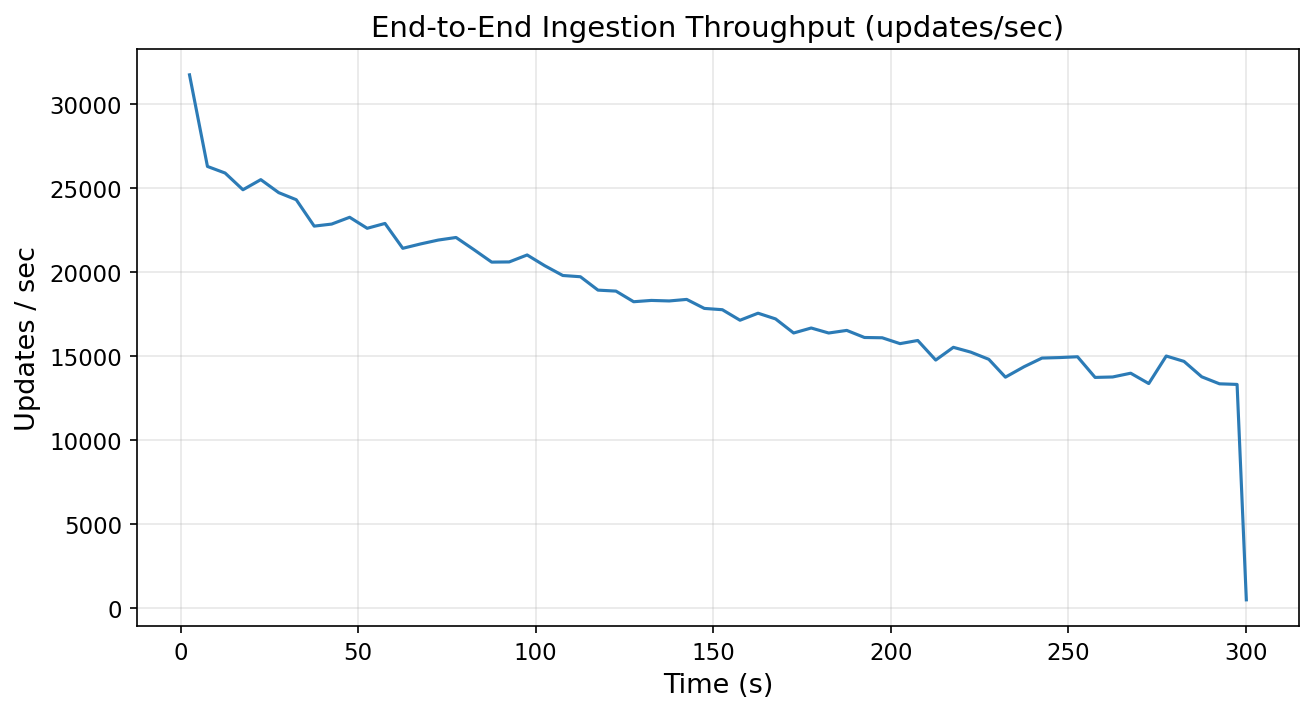

In [9]:
# --- Plot 1: End-to-end throughput (updates/sec) ---
tp_ups = fixed_window_throughput(df, "rel_completed_sec", "selected_updates",
                                 throughput_window_sec)

fig, ax = plt.subplots()
ax.plot(tp_ups["bin_mid"], tp_ups["rate"], color="#2c7bb6")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Updates / sec")
ax.set_title("End-to-End Ingestion Throughput (updates/sec)")
ax.grid(True, alpha=0.3)
save_fig(fig, "throughput_updates_per_sec")
plt.show()

  saved: throughput_blocks_per_sec.png / .pdf


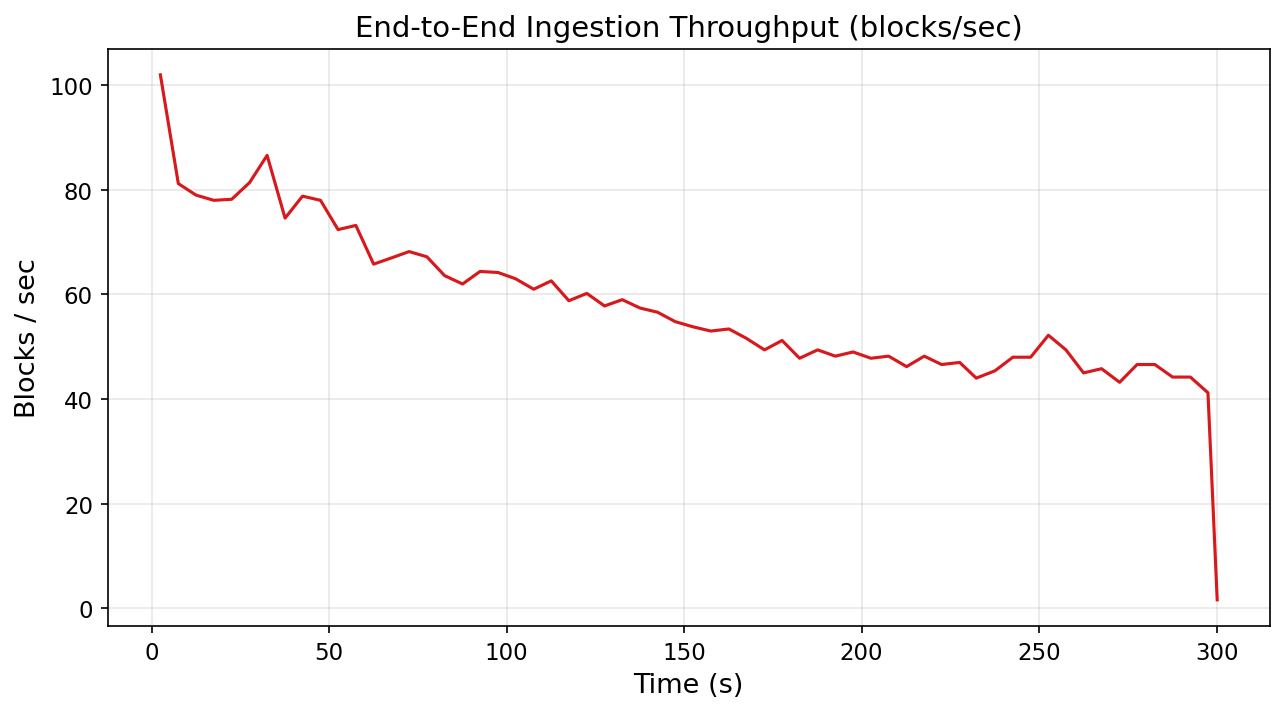

In [10]:
# --- Plot 2: End-to-end throughput (blocks/sec) ---
tp_bps = fixed_window_count_rate(df, "rel_completed_sec", throughput_window_sec)

fig, ax = plt.subplots()
ax.plot(tp_bps["bin_mid"], tp_bps["rate"], color="#d7191c")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Blocks / sec")
ax.set_title("End-to-End Ingestion Throughput (blocks/sec)")
ax.grid(True, alpha=0.3)
save_fig(fig, "throughput_blocks_per_sec")
plt.show()

## Latency over time

  saved: latency_e2e_block.png / .pdf


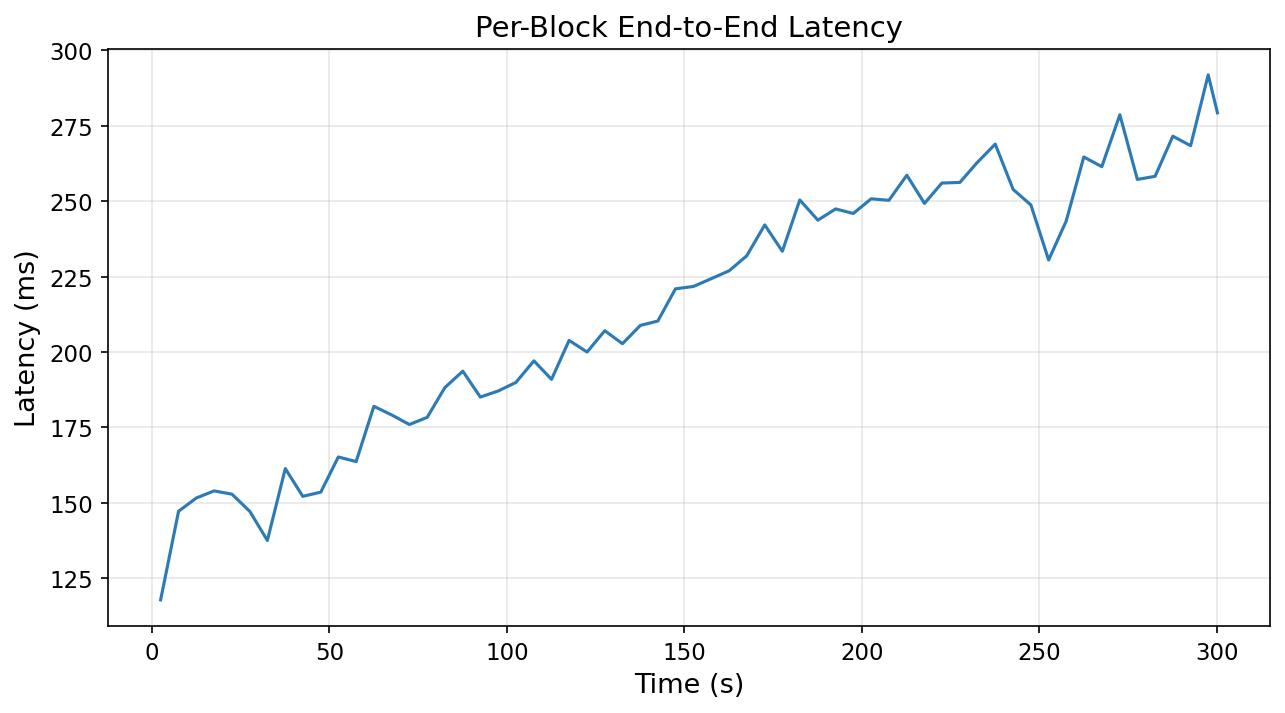

In [11]:
# --- Plot 3: End-to-end block latency ---
lat_e2e = fixed_window_mean(df, "rel_completed_sec", "e2e_latency_ms",
                            latency_window_sec)

fig, ax = plt.subplots()
ax.plot(lat_e2e["bin_mid"], lat_e2e["mean"], color="#2c7bb6")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Per-Block End-to-End Latency")
ax.grid(True, alpha=0.3)
save_fig(fig, "latency_e2e_block")
plt.show()

  saved: latency_mpt_phase.png / .pdf


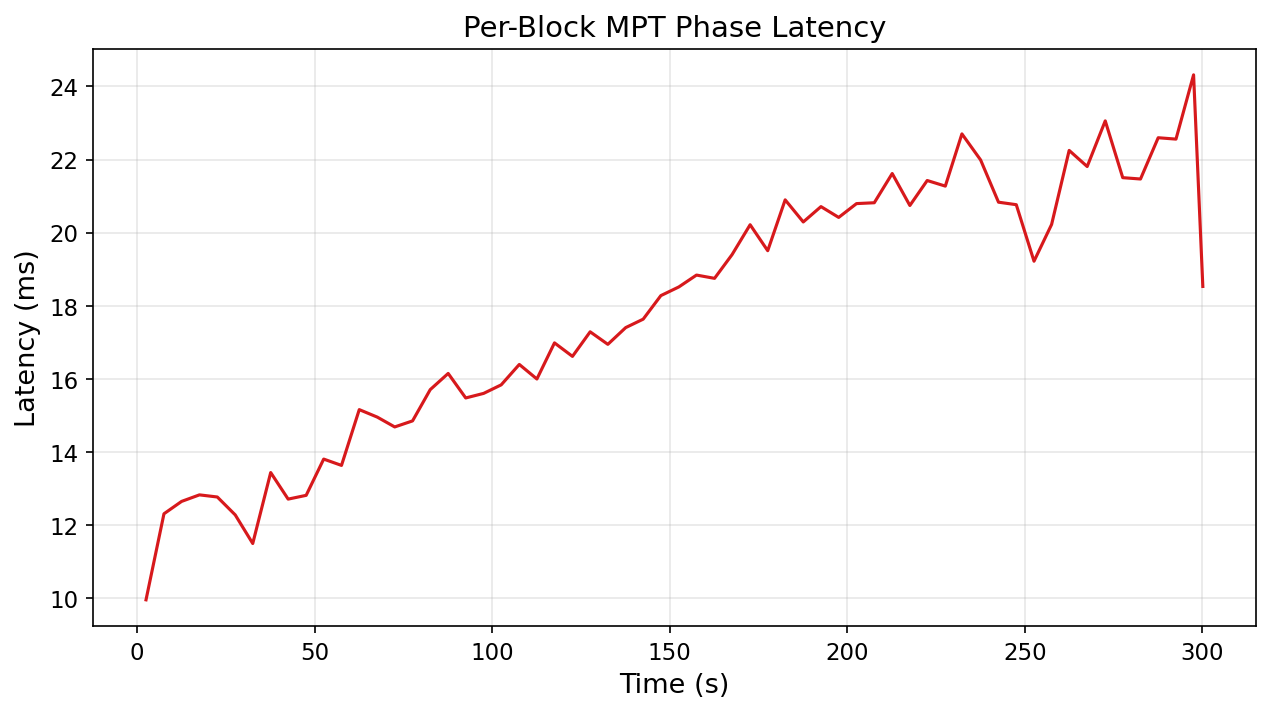

In [12]:
# --- Plot 4: MPT phase latency ---
lat_mpt = fixed_window_mean(df, "rel_completed_sec", "mpt_phase_latency_ms",
                            latency_window_sec)

fig, ax = plt.subplots()
ax.plot(lat_mpt["bin_mid"], lat_mpt["mean"], color="#d7191c")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Per-Block MPT Phase Latency")
ax.grid(True, alpha=0.3)
save_fig(fig, "latency_mpt_phase")
plt.show()

  saved: latency_wait_commitments.png / .pdf


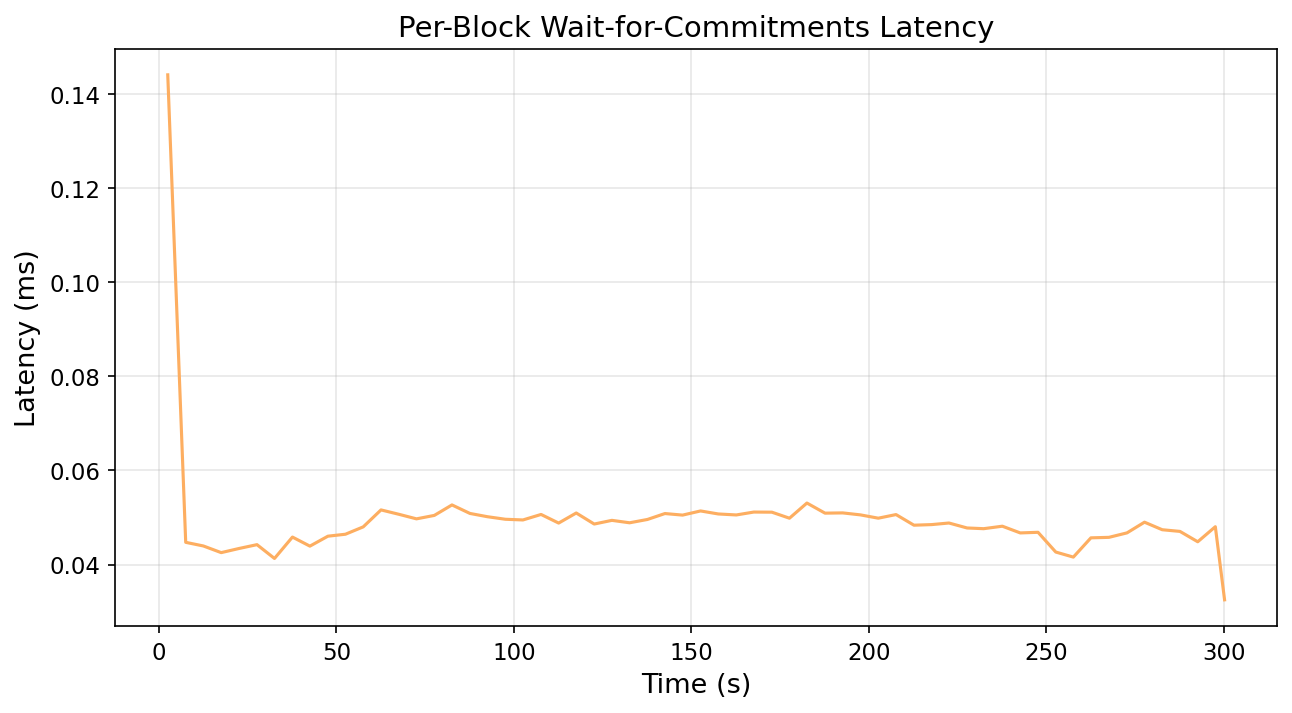

In [13]:
# --- Plot 5: Wait-for-commitments latency ---
lat_wait = fixed_window_mean(df, "rel_completed_sec",
                             "wait_commitments_latency_ms", latency_window_sec)

fig, ax = plt.subplots()
ax.plot(lat_wait["bin_mid"], lat_wait["mean"], color="#fdae61")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Per-Block Wait-for-Commitments Latency")
ax.grid(True, alpha=0.3)
save_fig(fig, "latency_wait_commitments")
plt.show()

  saved: latency_commitment.png / .pdf


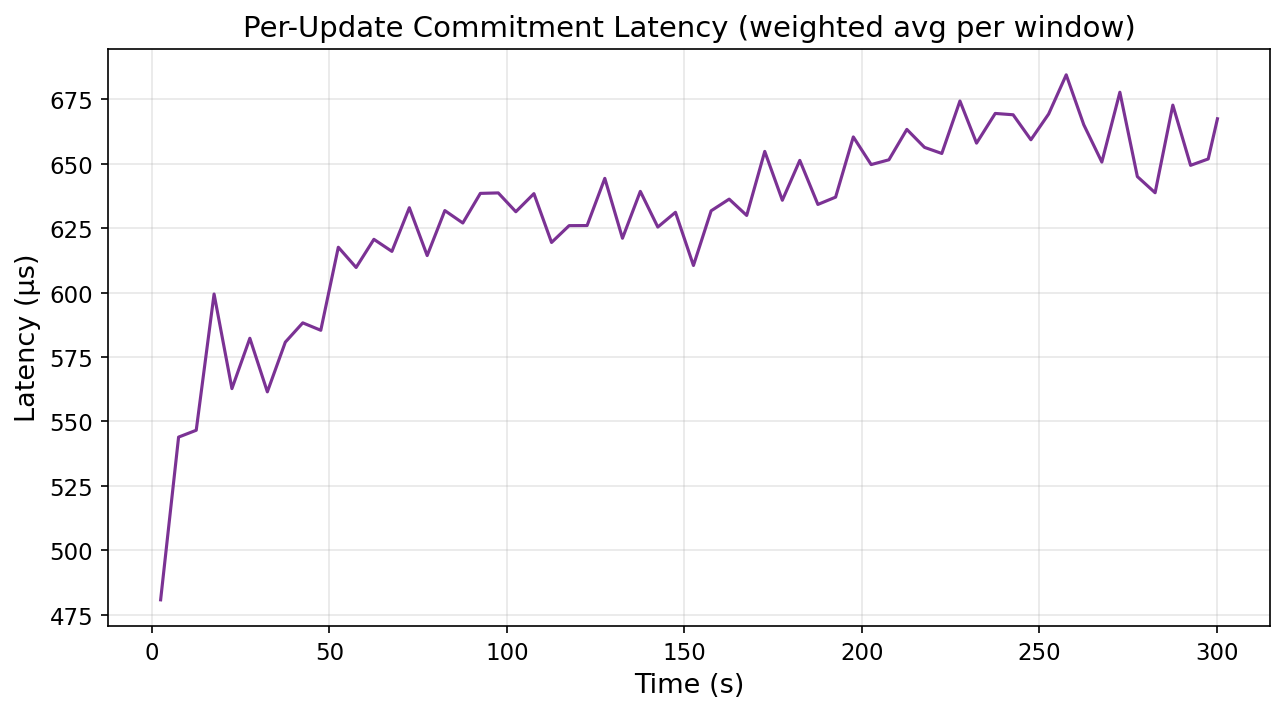

In [14]:
# --- Plot 6: Per-update commitment latency over time ---
df_cl = df[df["commit_latency_count"] > 0].copy()

if len(df_cl) > 0:
    lat_commit = fixed_window_weighted_mean(
        df_cl, "rel_completed_sec", "commit_latency_avg_us",
        "commit_latency_count", latency_window_sec,
    )

    fig, ax = plt.subplots()
    ax.plot(lat_commit["bin_mid"], lat_commit["wmean"], color="#7b3294")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Latency (\u00b5s)")
    ax.set_title("Per-Update Commitment Latency (weighted avg per window)")
    ax.grid(True, alpha=0.3)
    save_fig(fig, "latency_commitment")
    plt.show()
else:
    print("No commitment latency data available, skipping plot.")

## Workload profile

  saved: updates_per_block.png / .pdf


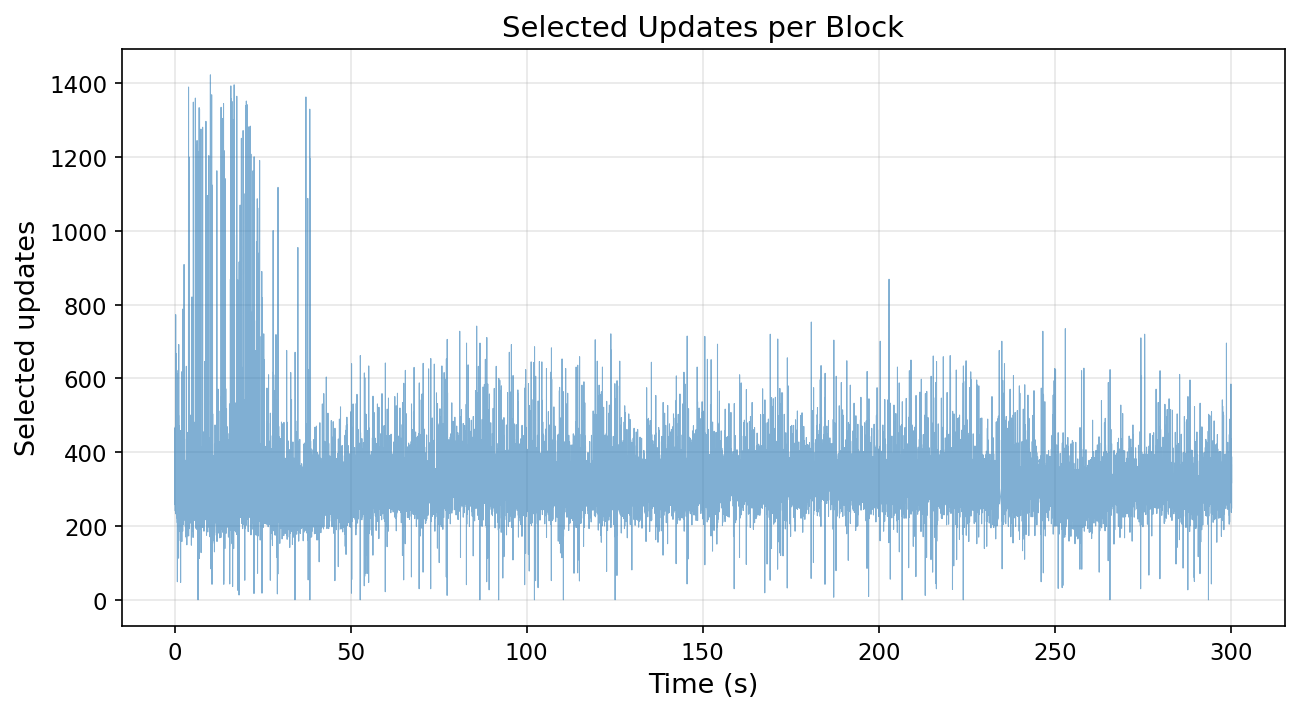

In [15]:
# --- Plot 7: Selected updates per block over time ---
fig, ax = plt.subplots()
ax.plot(df["rel_completed_sec"], df["selected_updates"],
        linewidth=0.5, alpha=0.6, color="#2c7bb6")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Selected updates")
ax.set_title("Selected Updates per Block")
ax.grid(True, alpha=0.3)
save_fig(fig, "updates_per_block")
plt.show()

## Distribution plots

  saved: cdf_e2e_latency.png / .pdf


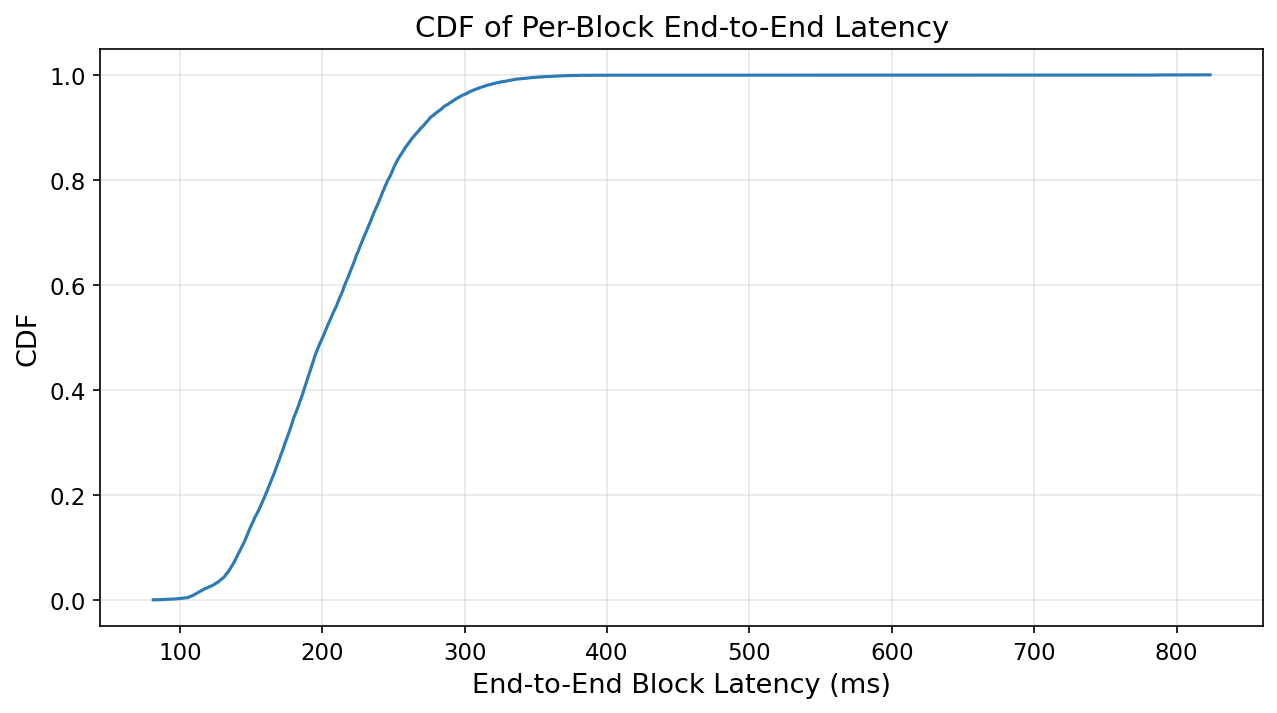

In [16]:
# CDF of end-to-end block latency
sorted_e2e = np.sort(df["e2e_latency_ms"].values)
cdf = np.arange(1, len(sorted_e2e) + 1) / len(sorted_e2e)

fig, ax = plt.subplots()
ax.plot(sorted_e2e, cdf, color="#2c7bb6")
ax.set_xlabel("End-to-End Block Latency (ms)")
ax.set_ylabel("CDF")
ax.set_title("CDF of Per-Block End-to-End Latency")
ax.grid(True, alpha=0.3)
save_fig(fig, "cdf_e2e_latency")
plt.show()

  saved: hist_commit_latency.png / .pdf


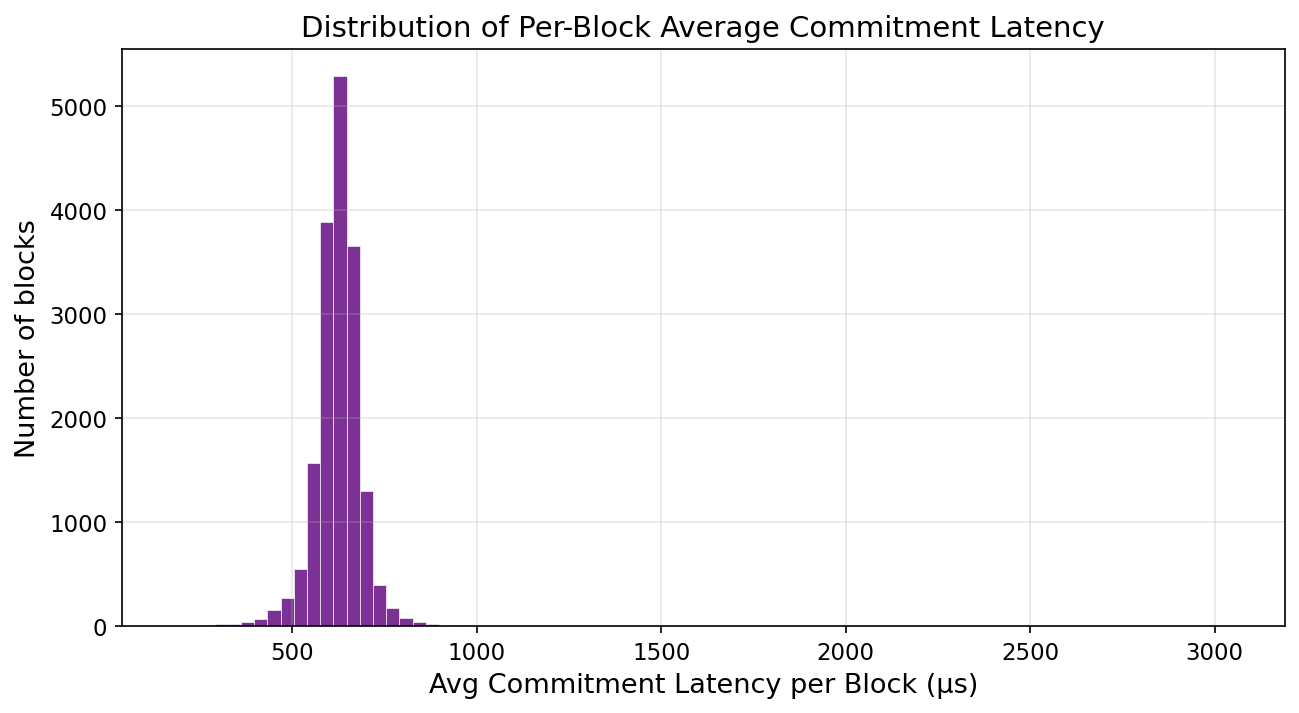

In [17]:
# Histogram of per-update commitment latency (from per-block averages)
valid_cl = df[df["commit_latency_count"] > 0]

if len(valid_cl) > 0:
    fig, ax = plt.subplots()
    ax.hist(valid_cl["commit_latency_avg_us"], bins=80, color="#7b3294",
            edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Avg Commitment Latency per Block (\u00b5s)")
    ax.set_ylabel("Number of blocks")
    ax.set_title("Distribution of Per-Block Average Commitment Latency")
    ax.grid(True, alpha=0.3)
    save_fig(fig, "hist_commit_latency")
    plt.show()
else:
    print("No commitment latency data, skipping histogram.")

## Scatter plots

  saved: scatter_updates_vs_e2e.png / .pdf


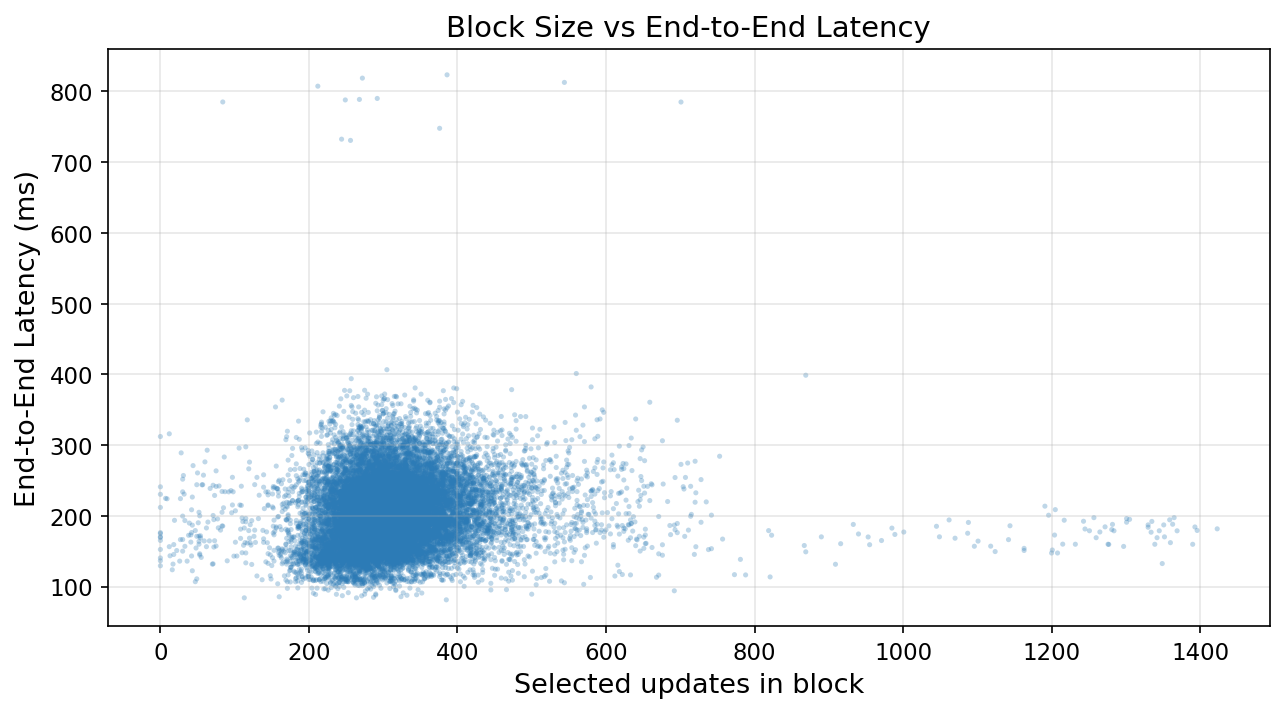

In [18]:
# --- Plot 8: Selected updates vs end-to-end block latency ---
fig, ax = plt.subplots()
ax.scatter(df["selected_updates"], df["e2e_latency_ms"],
           s=6, alpha=0.3, color="#2c7bb6", edgecolors="none")
ax.set_xlabel("Selected updates in block")
ax.set_ylabel("End-to-End Latency (ms)")
ax.set_title("Block Size vs End-to-End Latency")
ax.grid(True, alpha=0.3)
save_fig(fig, "scatter_updates_vs_e2e")
plt.show()

  saved: scatter_updates_vs_mpt.png / .pdf


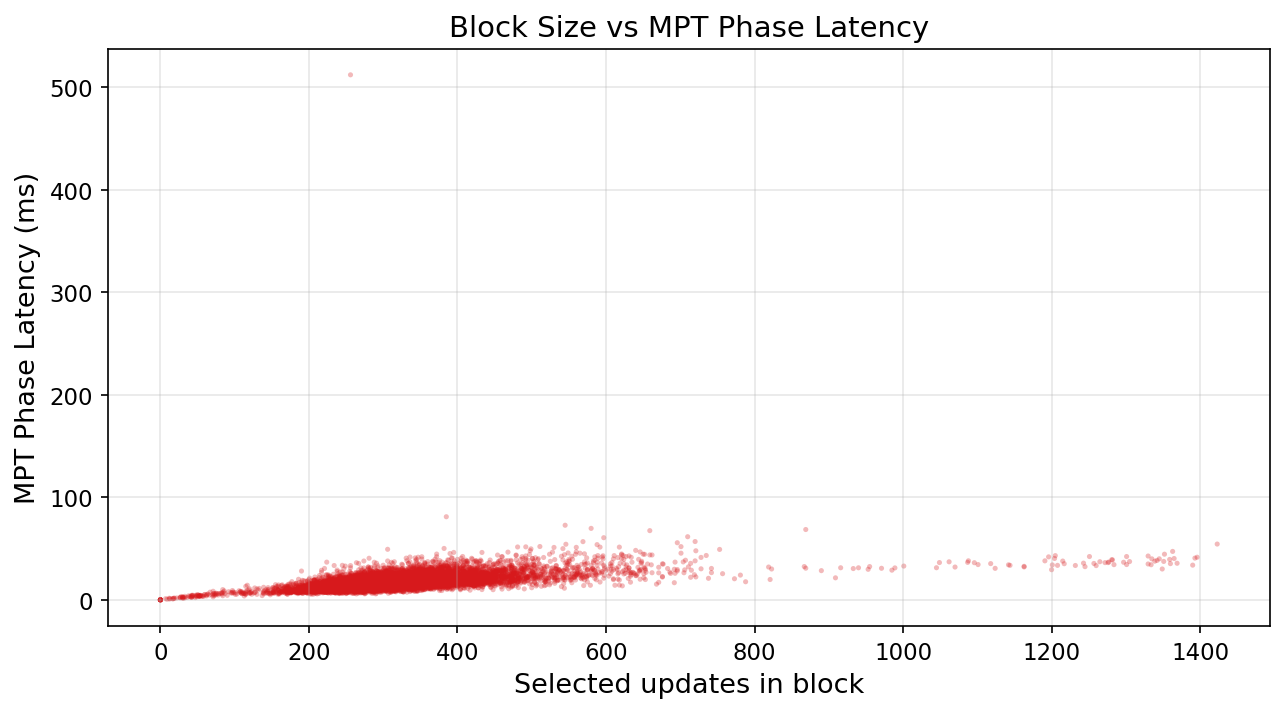

In [19]:
# Selected updates vs MPT phase latency
fig, ax = plt.subplots()
ax.scatter(df["selected_updates"], df["mpt_phase_latency_ms"],
           s=6, alpha=0.3, color="#d7191c", edgecolors="none")
ax.set_xlabel("Selected updates in block")
ax.set_ylabel("MPT Phase Latency (ms)")
ax.set_title("Block Size vs MPT Phase Latency")
ax.grid(True, alpha=0.3)
save_fig(fig, "scatter_updates_vs_mpt")
plt.show()